<a href="https://colab.research.google.com/github/SinthanaPrabakaran/Product-review-analyzer/blob/main/product_review_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core libraries
import re
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
import spacy
from nltk.corpus import stopwords

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Display options
pd.set_option("display.max_colwidth", 200)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Download NLTK resources (run once)
nltk.download("punkt")
nltk.download("stopwords")

# Load spaCy English model (download if needed)
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm")

# Stopwords with preserved negations
stop_words = set(stopwords.words("english"))
negations = {"no", "not", "never"}
stop_words = stop_words - negations  # keep negation words

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
DATA_URL = "https://jmcauley.ucsd.edu/data/amazon_v2/categoryFiles/Electronics.json.gz"

import requests
import io

# Load a subset for speed, but keep at least 1000 reviews
# If you have enough RAM, you can remove nrows to load everything.

try:
    # Use requests to download the content, bypassing SSL verification.
    # WARNING: Setting verify=False disables SSL certificate verification and should only be used if you trust the source.
    response = requests.get(DATA_URL, verify=False)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Read the gzipped content directly from the response bytes
    df_raw = pd.read_json(io.BytesIO(response.content), lines=True, compression="gzip", nrows=20000)

except requests.exceptions.RequestException as e:
    print(f"Error downloading data: {e}")
    # Initialize an empty DataFrame to prevent downstream errors if download fails
    df_raw = pd.DataFrame()

# Keep only the columns we care about if data was loaded successfully
if not df_raw.empty:
    df = df_raw[["reviewText", "overall"]].dropna(subset=["reviewText", "overall"]).copy()

    print("Raw dataset shape:", df.shape)
    df.head()
else:
    print("Failed to load data. The DataFrame 'df' is empty.")
    df = pd.DataFrame() # Ensure df is defined even if loading fails.

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'jmcauley.ucsd.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw dataset shape: (19994, 2)


In [ ]:
def convert_rating_to_sentiment(rating: float) -> str | None:
    """
    Convert numeric rating to 'Positive' / 'Negative' sentiment.
    Ignore neutral rating = 3 by returning None.
    """
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return None  # neutral (3-star) reviews are ignored

df["sentiment"] = df["overall"].apply(convert_rating_to_sentiment)

# Drop neutral (3-star) reviews and any remaining NAs
df = df.dropna(subset=["sentiment"]).reset_index(drop=True)

print("Filtered dataset shape (no neutral 3-star):", df.shape)
df["sentiment"].value_counts()

Filtered dataset shape (no neutral 3-star): (18647, 3)


,count
sentiment,
Positive,15064
Negative,3583


In [ ]:
#PREPROCESSING
def clean_text(text: str) -> str:
    """
    Basic text cleaning:
    - Remove HTML tags
    - Remove URLs
    - Remove special characters / punctuation
    - Convert to lowercase
    - Collapse multiple spaces
    """
    if not isinstance(text, str):
        return ""

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    # Remove URLs
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)
    # Remove non-alphanumeric characters (keep spaces)
    text = re.sub(r"[^a-zA-Z0-9\\s]", " ", text)
    # Lowercase
    text = text.lower()
    # Collapse multiple spaces
    text = re.sub(r"\\s+", " ", text).strip()
    return text


def lemmatize_text(text: str, nlp_model, stopword_set: set) -> str:
    """
    Lemmatize text using spaCy:
    - Tokenize and run POS tagging with spaCy
    - Remove stopwords (but NOT negations, handled in stopword_set construction)
    - Remove punctuation and spaces
    - Return a space-joined string of lemmas
    """
    if not isinstance(text, str) or not text:
        return ""

    doc = nlp_model(text)
    lemmas = []
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        token_lower = token.text.lower()
        if token_lower in stopword_set:
            continue
        lemmas.append(token.lemma_.lower())
    return " ".join(lemmas)

In [ ]:
# Apply cleaning
df["clean_basic"] = df["reviewText"].apply(clean_text)

# Apply lemmatization (this also does tokenization)
df["clean_review"] = df["clean_basic"].apply(lambda t: lemmatize_text(t, nlp, stop_words))

print("Cleaned dataset preview:")
df[["reviewText", "clean_review", "overall", "sentiment"]].head()

Cleaned dataset preview:


,reviewText,clean_review,overall,sentiment
0,This was the first time I read Garcia-Aguilera. I came upon the name of this book on Live with Regis and Kelly. This book was exactly what I was looking for ... it hit the spot. I really enjoyed...,first time read garcia aguilera come upon name book live regis kelly book exactly look hit spot really enjoy book well write start book keep come back culture family friendship romance look little...,5,Positive
1,"As with all of Ms. Garcia-Aguilera's books, I think this is a MUST READ, impossible to put down. Successful deviation from past Lupe Solano series-captures the very essence of the excitement, loca...",ms garcia aguilera book think must read impossible put successful deviation past lupe solano series capture essence excitement local color diverse fabric miami sensual culturally enlighten,5,Positive
2,"I've not read any of Ms Aguilera's works before, but after having just finished One Hot Summer I'm going to check out the Lupe Solano series I've heard so much about. One Hot Summer is sooo steam...",not read ms aguilera work finish one hot summer go check lupe solano series hear much one hot summer sooo steamy make want move miami put book,5,Positive
3,"This romance novel is right up there with the rest of her amazing mystery novels. Being a guy, I was a little hesitant about reading a romance novel but I just had to give this book a shot becaus...",romance novel right rest amazing mystery novel guy little hesitant read romance novel give book shot huge fan garcia aguilera book honest absolutely love book love way present funky miami crazy cu...,4,Positive
4,Carolina Garcia Aguilera has done it again. She's written another highly enjoyable book and infused it with the right amount of Cuban-American tidbits. My family and I cannot put her books down ...,carolina garcia aguilera do write another highly enjoyable book infuse right amount cuban american tidbit family not put book start one not let,5,Positive


In [ ]:
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab")

example_text = df["reviewText"].iloc[0]
print("Original review:")
print(example_text)
print("\nNLTK word_tokenize output:")
print(word_tokenize(example_text))

print("\nspaCy tokenization output:")
doc_example = nlp(example_text)
print([token.text for token in doc_example])

Original review:
This was the first time I read Garcia-Aguilera.  I came upon the name of this book on Live with Regis and Kelly. This book was exactly what I was looking for ... it hit the spot.  I really enjoyed this book because it was well written. Once I started this book it kept me coming back for more. It had culture, family, friendship and romance. I was looking for a little more romance when I picked this book but in the end it turned out to be just right.  I love the main chartachter Margarita (aka Daisy). I've never been to Miami but the way Daisy told the story I certainly felt I'd been there.
Also after going through all of Daisy's perils ... I closed the book with a feeling I had grown emotionally as well.

NLTK word_tokenize output:
['This', 'was', 'the', 'first', 'time', 'I', 'read', 'Garcia-Aguilera', '.', 'I', 'came', 'upon', 'the', 'name', 'of', 'this', 'book', 'on', 'Live', 'with', 'Regis', 'and', 'Kelly', '.', 'This', 'book', 'was', 'exactly', 'what', 'I', 'was', '

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
#FEATURE EXTRACTION USING POS TAGGING and COUNTING features (Nound and Adj)
from collections import Counter

def extract_features_from_doc(doc):
    """
    From a spaCy Doc, extract:
    - Nouns (NN, NNS) as product features
    - Adjectives (JJ, JJR, JJS) as descriptive words
    Returns (nouns, adjectives) as lists of lowercase lemmas.
    """
    noun_tags = {"NN", "NNS"}
    adj_tags = {"JJ", "JJR", "JJS"}

    nouns = []
    adjs = []
    for token in doc:
        if token.tag_ in noun_tags:
            nouns.append(token.lemma_.lower())
        elif token.tag_ in adj_tags:
            adjs.append(token.lemma_.lower())
    return nouns, adjs


# Process clean reviews with spaCy in a streaming fashion for efficiency
docs = list(nlp.pipe(df["clean_review"].tolist(), batch_size=500, n_process=1))

all_nouns = []
all_adjs = []

for doc in docs:
    nouns, adjs = extract_features_from_doc(doc)
    all_nouns.extend(nouns)
    all_adjs.extend(adjs)

noun_counter = Counter(all_nouns)
adj_counter = Counter(all_adjs)

print("Number of unique noun features:", len(noun_counter))
print("Number of unique adjectives:", len(adj_counter))

Number of unique noun features: 9734
Number of unique adjectives: 4389


/tmp/ipykernel_152/3839554530.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(features), y=list(counts), palette="Blues_d")


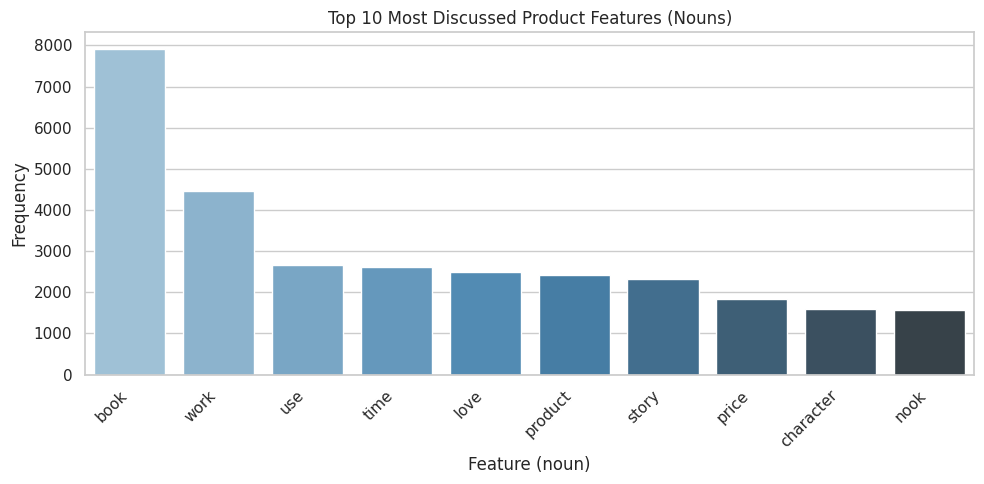

In [ ]:
top_n = 10
top_features = noun_counter.most_common(top_n)
features, counts = zip(*top_features)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(features), y=list(counts), palette="Blues_d")
plt.title("Top 10 Most Discussed Product Features (Nouns)")
plt.xlabel("Feature (noun)")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

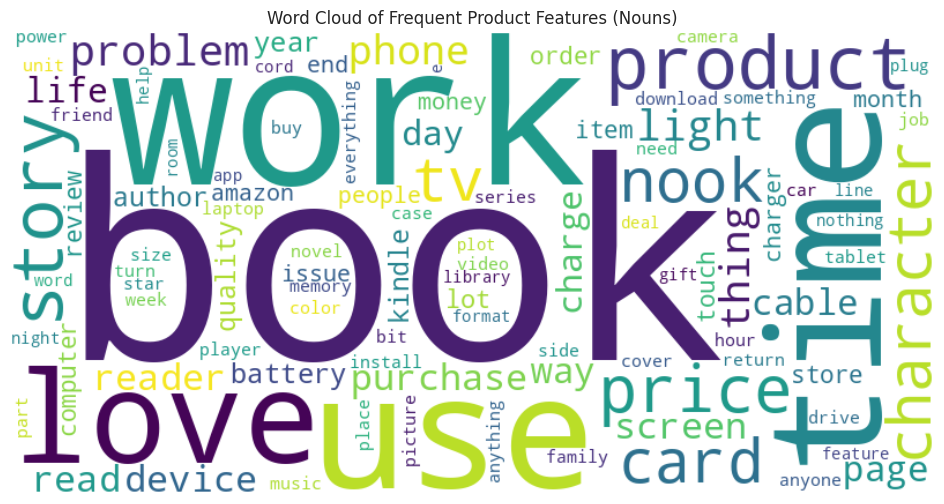

In [ ]:
#WordCloud for freq features
feature_freq_dict = dict(noun_counter.most_common(100))

wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(feature_freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Frequent Product Features (Nouns)")
plt.show()

In [ ]:
#Parsing
feature_adj_pairs = []

for doc in docs:
    for token in doc:
        #terrible battery
        if token.dep_ == "amod" and token.head.pos_ in {"NOUN", "PROPN"}:
            feature = token.head.lemma_.lower()
            adjective = token.lemma_.lower()
            feature_adj_pairs.append((feature, adjective))

        #battery is terrible
        if token.dep_ == "nsubj" and token.head.pos_ == "ADJ":
            feature = token.lemma_.lower()
            adjective = token.head.lemma_.lower()
            feature_adj_pairs.append((feature, adjective))

feature_adj_df = pd.DataFrame(feature_adj_pairs, columns=["feature", "adjective"])
print("Number of feature–adjective pairs extracted:", len(feature_adj_df))
feature_adj_df.head(10)

Number of feature–adjective pairs extracted: 73292


,feature,adjective
0,time,first
1,book,live
2,spot,hit
3,pick,little
4,love,right
5,chartachter,main
6,book,close
7,deviation,impossible
8,deviation,put
9,deviation,successful


In [ ]:
# Show most common adjective per feature (simple heuristic)
pair_counts = feature_adj_df.value_counts().reset_index(name="count")

top_feature_adj = (
    pair_counts.sort_values(["feature", "count"], ascending=[True, False])
    .groupby("feature")
    .head(1)
    .reset_index(drop=True)
)

print("Sample Feature | Associated adjective table:")
top_feature_adj.head(20)

Sample Feature | Associated adjective table:


,feature,adjective,count
0,120v,silly,1
1,1598lmthd,great,1
2,1st,addict,1
3,20min,go,1
4,250v,blow,1
5,280x,double,1
6,2nd,poor,1
7,3d,pro,1
8,3ds,new,1
9,3rd,2nd,1


In [ ]:
from spacy import displacy

example_indices = df.sample(2, random_state=42).index

for idx in example_indices:
    text = df.loc[idx, "reviewText"]
    doc = nlp(text)
    print(f"\nReview index {idx}:")
    print(text)
    display(displacy.render(doc, style="dep", jupyter=True, options={"distance": 120}))


Review index 2078:
aweful


None


Review index 6356:
I bought this for my girlfriend who is a very avid reader, but also very...how should I put this...ummm.....frugal. Yeah, frugal! She told me some time ago that she couldn't see paying $10, or even $5, for a book at a store when she could pick them up at any yard sale for $.25! Even knowing how she felt I just had a feeling she would come to love the nook. I don't read all that much and I know I love it! So, I bought this nook and a $40 gift card to buy ebooks. Wrapped them all up and waited. When she unwrapped it she was very surprised, but also indifferent. She set it all up and within an hour she had purchased and began reading her first ebook. After having it for 3 days she had already read 4 books! She told me it was the best gift she'd ever gotten. I'm pretty sure she's already burned through that $40! The great news is that now when we go somewhere she doesn't have to choose which 2 books she wants to take. She has all of them in a smaller space than even one

None

In [ ]:
def train_model(texts: pd.Series, labels: pd.Series, test_size: float = 0.2, random_state: int = 42):
    """
    Train a Logistic Regression sentiment classifier using TF-IDF features.

    Returns:
    - model: trained LogisticRegression
    - vectorizer: fitted TfidfVectorizer
    - X_train, X_test, y_train, y_test: split text and labels
    - y_pred: model predictions on X_test
    - acc: accuracy
    - f1: F1 score (Positive as positive class)
    - cm: confusion matrix (Negative, Positive)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=test_size,
        random_state=random_state,
        stratify=labels,
    )

    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    """vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)"""
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label="Positive")
    cm = confusion_matrix(y_test, y_pred, labels=["Negative", "Positive"])

    return model, vectorizer, X_train, X_test, y_train, y_test, y_pred, acc, f1, cm


model, vectorizer, X_train, X_test, y_train, y_test, y_pred, acc, f1, cm = train_model(
    df["clean_review"], df["sentiment"]
)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (Positive class): {f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9209
F1 Score (Positive class): 0.9525

Classification report:
              precision    recall  f1-score   support

    Negative       0.90      0.66      0.76       717
    Positive       0.92      0.98      0.95      3013

    accuracy                           0.92      3730
   macro avg       0.91      0.82      0.86      3730
weighted avg       0.92      0.92      0.92      3730



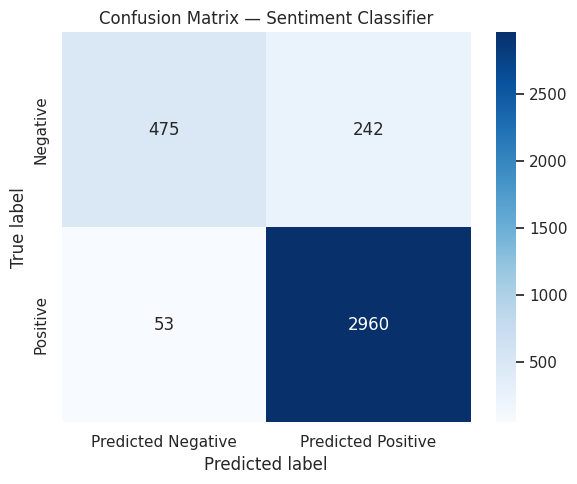

In [ ]:
cm_df = pd.DataFrame(
    cm,
    index=["Negative", "Positive"],
    columns=["Predicted Negative", "Predicted Positive"],
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Sentiment Classifier")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [ ]:
# Create a DataFrame linking original and cleaned reviews for test set
test_indices = X_test.index
sample_indices = np.random.choice(test_indices, size=min(5, len(test_indices)), replace=False)

sample_df = df.loc[sample_indices, ["reviewText", "clean_review", "sentiment"]].copy()
sample_vec = vectorizer.transform(sample_df["clean_review"])
sample_df["predicted_sentiment"] = model.predict(sample_vec)

print("Sample predictions on held-out test reviews:")
sample_df.reset_index(drop=True)

Sample predictions on held-out test reviews:


,reviewText,clean_review,sentiment,predicted_sentiment
0,"Great story. Loved all the characters. Could have done without some of the love scenes, but enjoyed the overall story. Can hardly wait. to start the next one.",great story love character could do without love scene enjoy overall story hardly wait start next one,Positive,Positive
1,loved it,love,Positive,Positive
2,"The quality of this cable if pathetic.\n\nDSLRs are made to be more portable than other cameras when filming, so I expect this cable to be able to take somewhat of beating since the camera isn't l...",quality cable pathetic dslrs make portable camera film expect cable able take somewhat beat since camera lock tripod day mini hdmi portion flimsy not reinforce way cable die middle first shoot pa ...,Negative,Positive
3,"This is an outstanding book! If you enjoy fantasy, you will love Bonham's writing.\n\nShe takes you from the first page on a fast paced adventure ride that doesn't stop.\n\nI hadn't read any work...",outstanding book enjoy fantasy love bonham writing take first page fast pace adventure ride stop read work bonham impressed please take time read work impress,Positive,Positive
4,If they made a right a right-handed version I would order one in about a half a second but as it is now FORGET IT!,make right right handed version would order one half second forget,Negative,Positive
